<a href="https://colab.research.google.com/github/mushrifahamed/DL-Assignment1/blob/custom_cnn/Brain_Tumor_CNN_Model_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Step 1: Set Up Your Notebook Environment**

1. **Import libraries**
   You’ll need standard libraries for deep learning, image handling, and plotting:

In [ ]:
# TensorFlow/Keras for building the CNN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# For numerical operations and plotting
import numpy as np
import matplotlib.pyplot as plt
import os

## **Step 2: Prepare the Dataset**

Since your dataset is from Kaggle:

1. **Upload Kaggle API token (`kaggle.json`) to Colab**.
2. **Install Kaggle package** if not installed:

In [ ]:
!pip install kaggle

3. **Set up Kaggle credentials in Colab**:

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

4. **Download the dataset**:

In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!unzip -q brain-tumor-mri-dataset.zip -d /content/brain_tumor_dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): CC0-1.0
 78% 116M/149M [00:00<00:00, 1.21GB/s]
100% 149M/149M [00:00<00:00, 1.19GB/s]


5. **Check folder structure** (to understand class subfolders):

In [ ]:
!ls /content/brain_tumor_dataset

Testing  Training


## **Step 3: Image Preprocessing**
We handle the preprocessing of the image data. This involves resizing and normalizing the images using ImageDataGenerator and setting up data generators for training, validation, and testing.

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,  # Split validation from training
    rotation_range=10, # Reduced from 20
    width_shift_range=0.05, # Reduced from 0.1
    height_shift_range=0.05, # Reduced from 0.1
    zoom_range=0.05, # Reduced from 0.1
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255) # No augmentation for testing

train_generator = train_datagen.flow_from_directory(
    '/content/brain_tumor_dataset/Training', # Point to Training folder
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training' # Use the training subset
)

validation_generator = train_datagen.flow_from_directory(
    '/content/brain_tumor_dataset/Training', # Point to Training folder
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation' # Use the validation subset
)

test_generator = test_datagen.flow_from_directory(
    '/content/brain_tumor_dataset/Testing', # Point to Testing folder
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False # Keep data in order for evaluation
)

Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


##**Step 4: Build the CNN Model**
Here, we define the architecture of the Convolutional Neural Network (CNN) model using TensorFlow/Keras. This includes adding convolutional layers, pooling layers, flatten layer, and dense layers. The model is then compiled with an optimizer and loss function.

In [ ]:
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')   # 4 classes
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,321,476 (12.67 MB)

 Trainable params: 3,321,476 (12.67 MB)

 Non-trainable params: 0 (0.00 B)

##**Step 5: Handle Class Imbalance and Train the Model**
We address the class imbalance in the dataset by computing class weights. Then, we train the CNN model using the training data, with validation data for monitoring and early stopping to prevent overfitting.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get class indices from train generator
classes = train_generator.classes
class_weights = compute_class_weight('balanced', classes=np.unique(classes), y=classes)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.0811258278145695), 1: np.float64(1.0659981343283582), 2: np.float64(0.8955721003134797), 3: np.float64(0.9800600343053173)}


In [ ]:
# Step 5: Train the Model
from tensorflow.keras.callbacks import EarlyStopping

# Optional: Stop training if validation loss doesn't improve for 3 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_generator,
    epochs=15,                         # you can adjust based on performance
    validation_data=validation_generator,
    callbacks=[early_stop],             # remove this if you don’t want early stopping
    class_weight=class_weights # Add class weights here
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 53s 312ms/step - accuracy: 0.4927 - loss: 1.0971 - val_accuracy: 0.7064 - val_loss: 0.7220
Epoch 2/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 33s 229ms/step - accuracy: 0.7668 - loss: 0.5961 - val_accuracy: 0.7301 - val_loss: 0.7107
Epoch 3/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 32s 224ms/step - accuracy: 0.8353 - loss: 0.5023 - val_accuracy: 0.7625 - val_loss: 0.6352
Epoch 4/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 219ms/step - accuracy: 0.8550 - loss: 0.3928 - val_accuracy: 0.7958 - val_loss: 0.5718
Epoch 5/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 32s 222ms/step - accuracy: 0.8745 - loss: 0.3404 - val_accuracy: 0.7599 - val_loss: 0.7212
Epoch 6/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 215ms/step - accuracy: 0.8863 - loss: 0.3251 - val_accuracy: 0.7993 - val_loss: 0.5237
Epoch 7/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 33s 231ms/step - accuracy: 0.9091 - loss: 0.2505 - val_accuracy: 0.7844 - val_loss: 0.6393
Epoch 8/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 215ms/step - accuracy: 0.9091 - loss: 0

##**Step 6: Visualize Training History**
Here, we visualize the training history of the model by plotting the training and validation accuracy and loss over epochs. We also print the final and best performance metrics.

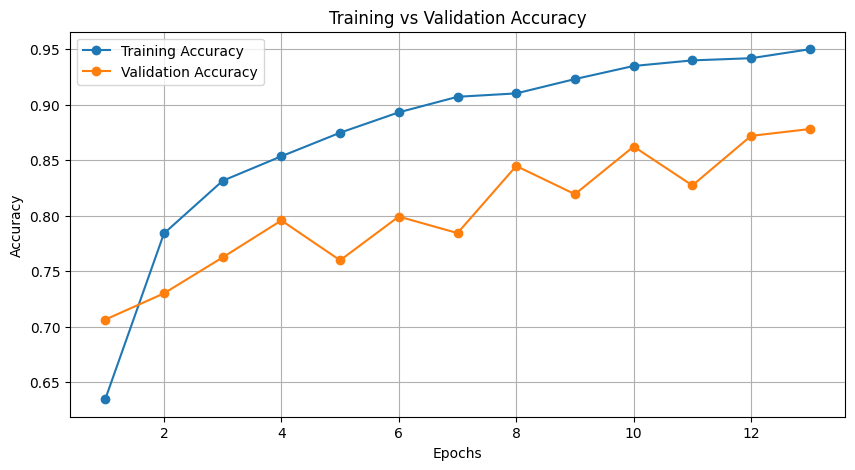

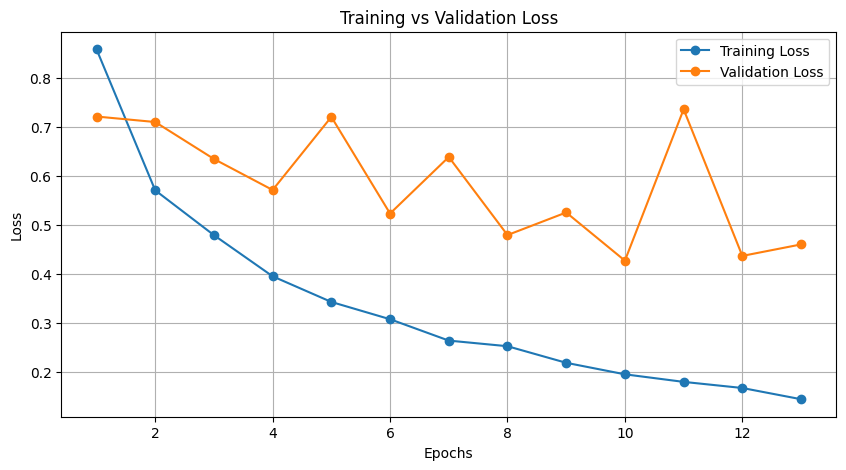

Final Training Accuracy: 95.01%
Final Validation Accuracy: 87.82%
Final Training Loss: 0.1441
Final Validation Loss: 0.4605

Best Validation Accuracy: 87.82% at Epoch 13


In [ ]:
import matplotlib.pyplot as plt

# Get history data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# ---- Plot Accuracy ----
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ---- Plot Loss ----
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# ---- Text Outputs for Easy Reading ----
print("Final Training Accuracy: {:.2f}%".format(acc[-1] * 100))
print("Final Validation Accuracy: {:.2f}%".format(val_acc[-1] * 100))
print("Final Training Loss: {:.4f}".format(loss[-1]))
print("Final Validation Loss: {:.4f}".format(val_loss[-1]))

# Compare best epoch
best_epoch = val_acc.index(max(val_acc)) + 1
print("\nBest Validation Accuracy: {:.2f}% at Epoch {}".format(max(val_acc) * 100, best_epoch))


In [ ]:
# Text-only visualization of accuracy & loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

print("\nEpoch | Train Acc | Val Acc | Train Loss | Val Loss")
print("-"*55)

for i in range(len(acc)):
    print("{:5d} | {:9.4f} | {:7.4f} | {:11.4f} | {:8.4f}".format(
        i+1, acc[i], val_acc[i], loss[i], val_loss[i]
    ))

# Show final & best
best_epoch = val_acc.index(max(val_acc)) + 1
print("\nFinal Training Accuracy: {:.2f}%".format(acc[-1] * 100))
print("Final Validation Accuracy: {:.2f}%".format(val_acc[-1] * 100))
print("Final Training Loss: {:.4f}".format(loss[-1]))
print("Final Validation Loss: {:.4f}".format(val_loss[-1]))
print("Best Validation Accuracy: {:.2f}% at Epoch {}".format(max(val_acc) * 100, best_epoch))



Epoch | Train Acc | Val Acc | Train Loss | Val Loss
-------------------------------------------------------
    1 |    0.6347 |  0.7064 |      0.8595 |   0.7220
    2 |    0.7841 |  0.7301 |      0.5711 |   0.7107
    3 |    0.8315 |  0.7625 |      0.4795 |   0.6352
    4 |    0.8536 |  0.7958 |      0.3953 |   0.5718
    5 |    0.8749 |  0.7599 |      0.3429 |   0.7212
    6 |    0.8932 |  0.7993 |      0.3076 |   0.5237
    7 |    0.9072 |  0.7844 |      0.2639 |   0.6393
    8 |    0.9103 |  0.8449 |      0.2524 |   0.4797
    9 |    0.9232 |  0.8195 |      0.2185 |   0.5258
   10 |    0.9350 |  0.8624 |      0.1950 |   0.4273
   11 |    0.9401 |  0.8273 |      0.1795 |   0.7366
   12 |    0.9420 |  0.8720 |      0.1670 |   0.4370
   13 |    0.9501 |  0.8782 |      0.1441 |   0.4605

Final Training Accuracy: 95.01%
Final Validation Accuracy: 87.82%
Final Training Loss: 0.1441
Final Validation Loss: 0.4605
Best Validation Accuracy: 87.82% at Epoch 13


##**Step 7: Evaluate the Model**

Finally, we evaluate the trained model's performance on the test set. This involves calculating and printing the test accuracy and loss, generating a classification report, and displaying a confusion matrix to assess the model's performance for each class.

 1/41 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.7188 - loss: 0.7087

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.7804 - loss: 0.6334

Test Accuracy: 85.28%
Test Loss: 0.4340
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step

Classification Report:
              precision    recall  f1-score   support

      glioma       0.97      0.77      0.86       300
  meningioma       0.78      0.67      0.72       306
     notumor       0.78      1.00      0.88       405
   pituitary       0.94      0.93      0.94       300

    accuracy                           0.85      1311
   macro avg       0.87      0.84      0.85      1311
weighted avg       0.86      0.85      0.85      1311



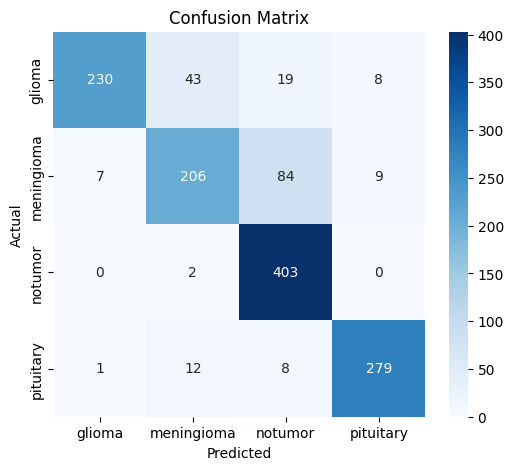

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Evaluate accuracy on test set
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# 2. Get predictions
# Since test_generator shuffles=False, the order is maintained
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Classification report
print("\nClassification Report:")
# Get class names from the generator
class_names = list(test_generator.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=class_names))

# 4. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Step 8: Save Model Results

In this step, we save the trained model so that it can be loaded and used later without retraining.

In [ ]:
# Save the model
model.save('brain_tumor_cnn_model.keras')
print("Model saved successfully!")

Model saved successfully!


## Step 9: Load Model and Predict on New Image

In this step, we will load the previously saved model and use it to predict the class of a new image.

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 14 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model loaded successfully!
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 770ms/step


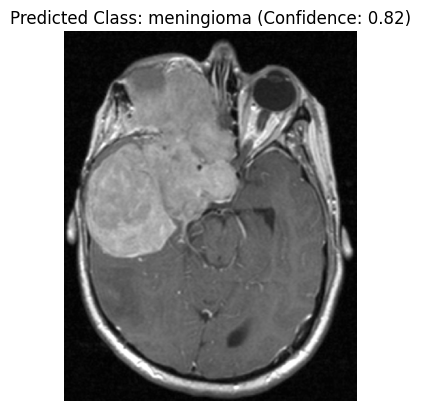


The model predicts that the image is a 'meningioma' with a confidence of 0.82.


In [ ]:
# Step 9: Load Model and Predict on New Image

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load the saved model
loaded_model = load_model('brain_tumor_cnn_model.keras')
print("Model loaded successfully!")

# Function to load and preprocess a single image
def load_and_preprocess_image(img_path, target_size=(128, 128)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
    img_array /= 255.0  # Rescale the image like the training data
    return img_array

# Function to predict the class of an image
def predict_image_class(model, img_array, class_names):
    predictions = model.predict(img_array)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_names[predicted_class_index]
    confidence = np.max(predictions)
    return predicted_class_name, confidence

# You can upload an image to your Colab environment or provide a path to a file in Google Drive (after mounting Drive)
image_path = '/content/brain_tumor_dataset/Testing/meningioma/Te-me_0018.jpg'

# Get class names from the test generator (or define them manually if you know them)
# Make sure the order of class names matches the order used during training
class_names = list(test_generator.class_indices.keys())
print("Class names:", class_names)

# Load and preprocess the image
new_image = load_and_preprocess_image(image_path)

# Predict the class
predicted_class, confidence = predict_image_class(loaded_model, new_image, class_names)

# Display the image and prediction
img = image.load_img(image_path)
plt.imshow(img)
plt.title(f"Predicted Class: {predicted_class} (Confidence: {confidence:.2f})")
plt.axis('off')
plt.show()

print(f"\nThe model predicts that the image is a '{predicted_class}' with a confidence of {confidence:.2f}.")